## 1. Import Required Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Model and preprocessing
import joblib
from sklearn.preprocessing import LabelEncoder

# Explainability libraries
import shap

# Import LIME (now installed)
from lime import lime_tabular
LIME_AVAILABLE = True
print("✓ LIME imported successfully")

# Additional analysis
from scipy import stats
from sklearn.inspection import permutation_importance

print("✓ All core libraries imported successfully!")
print(f"SHAP version: {shap.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"LIME available: {LIME_AVAILABLE}")

✓ LIME imported successfully
✓ All core libraries imported successfully!
SHAP version: 0.50.0
Pandas version: 2.3.3
NumPy version: 2.3.5
LIME available: True


## 2. Load Phase 1 Model and Phase 2 Results

In [2]:
def load_phase1_model(model_path='best_model_xgboost_20251207_150032.joblib'):
    """
    Load the trained predictive model from Phase 1.
    
    🔄 UPDATED: Now using XGBoost model trained on CLEANED dataset (90.2% accuracy)
    This model has correct feature correlations and domain-aligned patterns.
    """
    print("="*80)
    print("LOADING PHASE 1 MODEL (XGBoost - Cleaned Dataset)")
    print("="*80)
    
    model_pkg = joblib.load(model_path)
    
    print(f"\n✓ Model loaded successfully!")
    print(f"  Model Type: {model_pkg['model_name']}")
    print(f"  Accuracy: {model_pkg['metrics']['Accuracy']:.4f}")
    print(f"  Features: {len(model_pkg['feature_names'])}")
    print("="*80)

    return model_pkg

# Load model
model_pkg = load_phase1_model()

LOADING PHASE 1 MODEL (XGBoost - Cleaned Dataset)

✓ Model loaded successfully!
  Model Type: XGBoost
  Accuracy: 0.9023
  Features: 20


In [3]:
# Load CLEANED dataset with correct labels
# 🔄 UPDATED: Using cleaned dataset (885 URLs, 77.8% correct correlations)
df = pd.read_csv('cleaned_website_performance_dataset_20251207_145008.csv')

print(f"Dataset loaded: {df.shape[0]} samples, {df.shape[1]} features")
print(f"✓ Using CLEANED dataset with fixed labels and correlations")
print(f"\nPerformance Label Distribution:")
print(df['Performance_Label'].value_counts())


# Display first few rowsdf.head()
df.head()

Dataset loaded: 885 samples, 27 features
✓ Using CLEANED dataset with fixed labels and correlations

Performance Label Distribution:
Performance_Label
slow      315
fast      299
medium    271
Name: count, dtype: int64


,Sr No,website_url,Category,Page Size (KB),Load Time(s),Response Time(s),Throughput,Performance_Label,User Response,performance_score,...,num_requests,dom_size,uses_text_compression,render_blocking_resources,unused_js,uses_http2,modern_image_formats,extraction_successful,error_message,extraction_timestamp
0,0,https://www.booking.com/index.html?aid=1743217,Travel,3400.0,4.190,0.523,622.58,medium,Medium,62.0,...,163.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:23:23
1,1,https://travelsites.com/expedia/,Travel,1331.2,1.040,0.350,20.00,fast,Fast,92.0,...,54.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:23:41
2,2,https://travelsites.com/tripadvisor/,Travel,1945.6,0.833,0.392,331.29,fast,Medium,91.0,...,54.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:24:00
3,3,https://www.momondo.in/?ispredir=true,Travel,13926.4,0.049,0.297,1.21,medium,Fast,37.0,...,127.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:24:40
4,4,https://www.ebookers.com/?AFFCID=EBOOKERS-UK.n...,Travel,4300.8,0.751,1.211,61.45,slow,Medium,51.0,...,111.0,NaN,NaN,NaN,0.0,NaN,NaN,True,NaN,2025-11-20 10:25:12


## 3. Prepare Data for Explainability Analysis

In [4]:
def prepare_explainability_data(df, model_pkg):
    """
    Prepare data with all feature engineering for explainability analysis.
    
    Returns:
    --------
    X_scaled : np.ndarray
        Scaled feature matrix
    X_original : pd.DataFrame
        Original features (before scaling)
    y : np.ndarray
        Target labels
    feature_names : list
        Names of all features
    """
    print("="*80)
    print("PREPARING DATA FOR EXPLAINABILITY ANALYSIS")
    print("="*80)
    
    # Get base features (15 core features)
    base_features = model_pkg['feature_names'][:15]
    
    # Create a copy for processing
    df_processed = df.copy()
    
    # Handle missing values in Category column before encoding
    if 'Category' in df_processed.columns:
        # Fill missing Category values with the most frequent category
        most_frequent_category = df_processed['Category'].mode()[0] if len(df_processed['Category'].mode()) > 0 else 'Other'
        df_processed['Category'].fillna(most_frequent_category, inplace=True)
    
    # Handle categorical encoding
    category_encoder = model_pkg['encoders'].get('Category', None)
    if category_encoder is not None and 'Category' in df_processed.columns:
        # Handle unseen categories by replacing with the most frequent known category
        known_categories = category_encoder.classes_
        df_processed['Category'] = df_processed['Category'].apply(
            lambda x: x if x in known_categories else known_categories[0]
        )
        df_processed['Category'] = category_encoder.transform(df_processed['Category'])
    
    # Extract base features
    X_base = df_processed[base_features].copy()
    
    # Handle any remaining missing values in numeric features
    X_base.fillna(X_base.median(), inplace=True)
    
    # Apply feature engineering (same as Phase 1)
    print("\n📊 Applying feature engineering...")
    
    # Size_LoadTime_Ratio
    X_base['Size_LoadTime_Ratio'] = X_base['Page Size (KB)'] / (X_base['Load Time(s)'] + 1e-6)
    
    # Total_Time
    X_base['Total_Time'] = X_base['Response Time(s)'] + X_base['Load Time(s)']
    
    # Throughput_Response_Ratio
    X_base['Throughput_Response_Ratio'] = X_base['Throughput'] / (X_base['Response Time(s)'] + 1e-6)
    
    # Log_Page_Size
    X_base['Log_Page_Size'] = np.log1p(X_base['Page Size (KB)'])
    
    # Log_Throughput
    X_base['Log_Throughput'] = np.log1p(X_base['Throughput'])
    
    # All 20 features
    X_original = X_base.copy()
    
    # Get target labels - handle missing values FIRST
    target_encoder = model_pkg['encoders']['target']
    # Remove rows with missing Performance_Label
    valid_mask = df_processed['Performance_Label'].notna()
    
    # Filter X_original first (DataFrame)
    X_original = X_original[valid_mask].reset_index(drop=True)
    
    # Scale features after filtering
    scaler = model_pkg['scaler']
    X_scaled = scaler.transform(X_original)
    
    # Transform target labels
    y = target_encoder.transform(df_processed.loc[valid_mask, 'Performance_Label'])
    
    print(f"\n✓ Data prepared successfully!")
    print(f"  Samples: {X_scaled.shape[0]}")
    print(f"  Features: {X_scaled.shape[1]}")
    print(f"  Classes: {len(np.unique(y))} ({', '.join(target_encoder.classes_)})")
    print("="*80)
    
    return X_scaled, X_original, y, model_pkg['feature_names']

# Prepare data
X_scaled, X_original, y, feature_names = prepare_explainability_data(df, model_pkg)

PREPARING DATA FOR EXPLAINABILITY ANALYSIS

📊 Applying feature engineering...

✓ Data prepared successfully!
  Samples: 885
  Features: 20
  Classes: 3 (fast, medium, slow)


## 4. SHAP Analysis - Global Feature Importance

**Goal:** Identify which features the model relies on most heavily across all predictions.

In [5]:
def compute_shap_values(model, X_scaled, feature_names, sample_size=200):
    """
    Compute SHAP values for the model.
    
    Parameters:
    -----------
    model : trained model
        The Random Forest model
    X_scaled : np.ndarray
        Scaled feature matrix
    feature_names : list
        Names of features
    sample_size : int
        Number of samples to use for background data
    
    Returns:
    --------
    explainer : shap.Explainer
        SHAP explainer object
    shap_values : np.ndarray
        SHAP values for all samples
    """
    print("="*80)
    print("COMPUTING SHAP VALUES")
    print("="*80)
    print("\nThis may take a few minutes for Random Forest models...")
    
    # Use TreeExplainer for tree-based models (faster and exact)
    print(f"\n📊 Creating SHAP TreeExplainer...")
    explainer = shap.TreeExplainer(model)
    
    # Compute SHAP values
    print(f"📊 Computing SHAP values for {X_scaled.shape[0]} samples...")
    shap_values = explainer.shap_values(X_scaled)
    
    print(f"\n✓ SHAP values computed successfully!")
    print(f"  Shape: {np.array(shap_values).shape}")
    print(f"  Classes: {len(shap_values)} (fast, medium, slow)")
    print("="*80)
    
    return explainer, shap_values

# Compute SHAP values
explainer, shap_values = compute_shap_values(model_pkg['model'], X_scaled, feature_names)

COMPUTING SHAP VALUES

This may take a few minutes for Random Forest models...

📊 Creating SHAP TreeExplainer...
📊 Computing SHAP values for 885 samples...

✓ SHAP values computed successfully!
  Shape: (885, 20, 3)
  Classes: 885 (fast, medium, slow)


## 5. Visualize Global Feature Importance

GLOBAL FEATURE IMPORTANCE (SHAP)


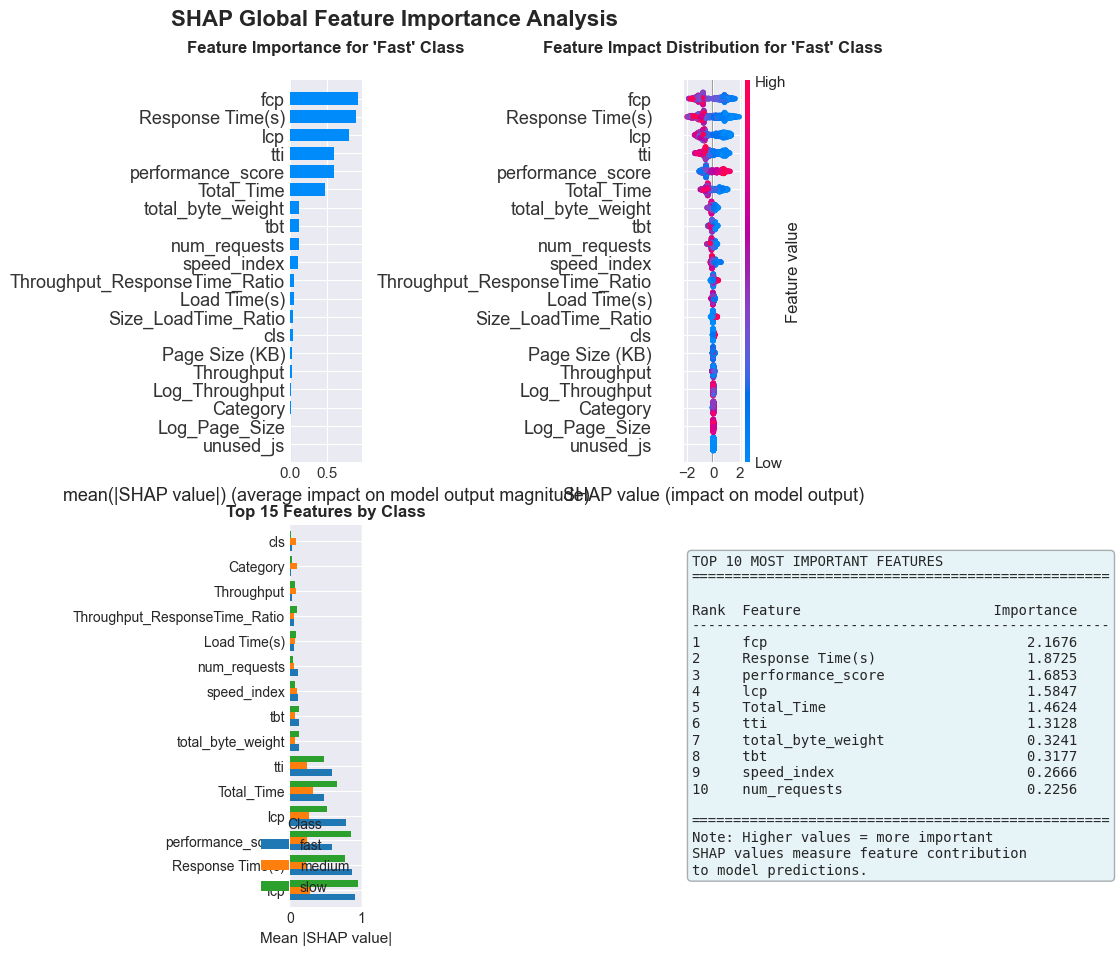


📊 Key Insights:
  • Top feature: fcp (importance: 2.1676)
  • Top 3 features account for 51.0% of importance


In [6]:
def plot_shap_summary(shap_values, X_scaled, feature_names, class_names=['fast', 'medium', 'slow']):
    """
    Create comprehensive SHAP summary plots.
    """
    print("="*80)
    print("GLOBAL FEATURE IMPORTANCE (SHAP)")
    print("="*80)
    
    # Handle different SHAP value formats
    # Newer versions return (samples, features, classes) array
    # Older versions return list of (samples, features) arrays
    if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
        # Convert 3D array to list of 2D arrays (one per class)
        shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    else:
        shap_values_list = shap_values
    
    # We'll focus on 'fast' class (index 0) as that's our optimization target
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('SHAP Global Feature Importance Analysis', fontsize=16, fontweight='bold')
    
    # 1. Summary plot for 'fast' class
    plt.sca(axes[0, 0])
    shap.summary_plot(shap_values_list[0], X_scaled, feature_names=feature_names, 
                     show=False, plot_type='bar')
    axes[0, 0].set_title("Feature Importance for 'Fast' Class", fontweight='bold', pad=20)
    
    # 2. Beeswarm plot for 'fast' class
    plt.sca(axes[0, 1])
    shap.summary_plot(shap_values_list[0], X_scaled, feature_names=feature_names, 
                     show=False, plot_type='dot')
    axes[0, 1].set_title("Feature Impact Distribution for 'Fast' Class", fontweight='bold', pad=20)
    
    # 3. Mean absolute SHAP values per class
    mean_shap_per_class = []
    for i, class_name in enumerate(class_names):
        mean_abs_shap = np.abs(shap_values_list[i]).mean(axis=0)
        mean_shap_per_class.append(mean_abs_shap)
    
    mean_shap_df = pd.DataFrame(mean_shap_per_class, 
                                 columns=feature_names,
                                 index=class_names).T
    
    # Plot top 15 features
    top_features = mean_shap_df.sum(axis=1).nlargest(15)
    mean_shap_top = mean_shap_df.loc[top_features.index]
    
    mean_shap_top.plot(kind='barh', ax=axes[1, 0], width=0.8)
    axes[1, 0].set_xlabel('Mean |SHAP value|', fontsize=11)
    axes[1, 0].set_title('Top 15 Features by Class', fontweight='bold')
    axes[1, 0].legend(title='Class', loc='lower right')
    axes[1, 0].grid(axis='x', alpha=0.3)
    
    # 4. Feature importance comparison table
    axes[1, 1].axis('off')
    
    # Get top 10 overall features
    overall_importance = mean_shap_df.sum(axis=1).nlargest(10)
    
    table_text = "TOP 10 MOST IMPORTANT FEATURES\n"
    table_text += "="*50 + "\n\n"
    table_text += f"{'Rank':<6}{'Feature':<25}{'Importance':>15}\n"
    table_text += "-"*50 + "\n"
    
    for rank, (feat, imp) in enumerate(overall_importance.items(), 1):
        table_text += f"{rank:<6}{feat:<25}{imp:>15.4f}\n"
    
    table_text += "\n" + "="*50 + "\n"
    table_text += "Note: Higher values = more important\n"
    table_text += "SHAP values measure feature contribution\n"
    table_text += "to model predictions."
    
    axes[1, 1].text(0.1, 0.5, table_text, 
                   fontsize=10, family='monospace',
                   verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Key Insights:")
    print(f"  • Top feature: {overall_importance.index[0]} (importance: {overall_importance.iloc[0]:.4f})")
    print(f"  • Top 3 features account for {(overall_importance.iloc[:3].sum() / overall_importance.sum() * 100):.1f}% of importance")
    print("="*80)
    
    return mean_shap_df

# Plot global feature importance
mean_shap_df = plot_shap_summary(shap_values, X_scaled, feature_names)

## 6. Analyze Counterintuitive Patterns

**Goal:** Investigate why the model suggests increasing metrics that should decrease.

ANALYZING COUNTERINTUITIVE PATTERNS


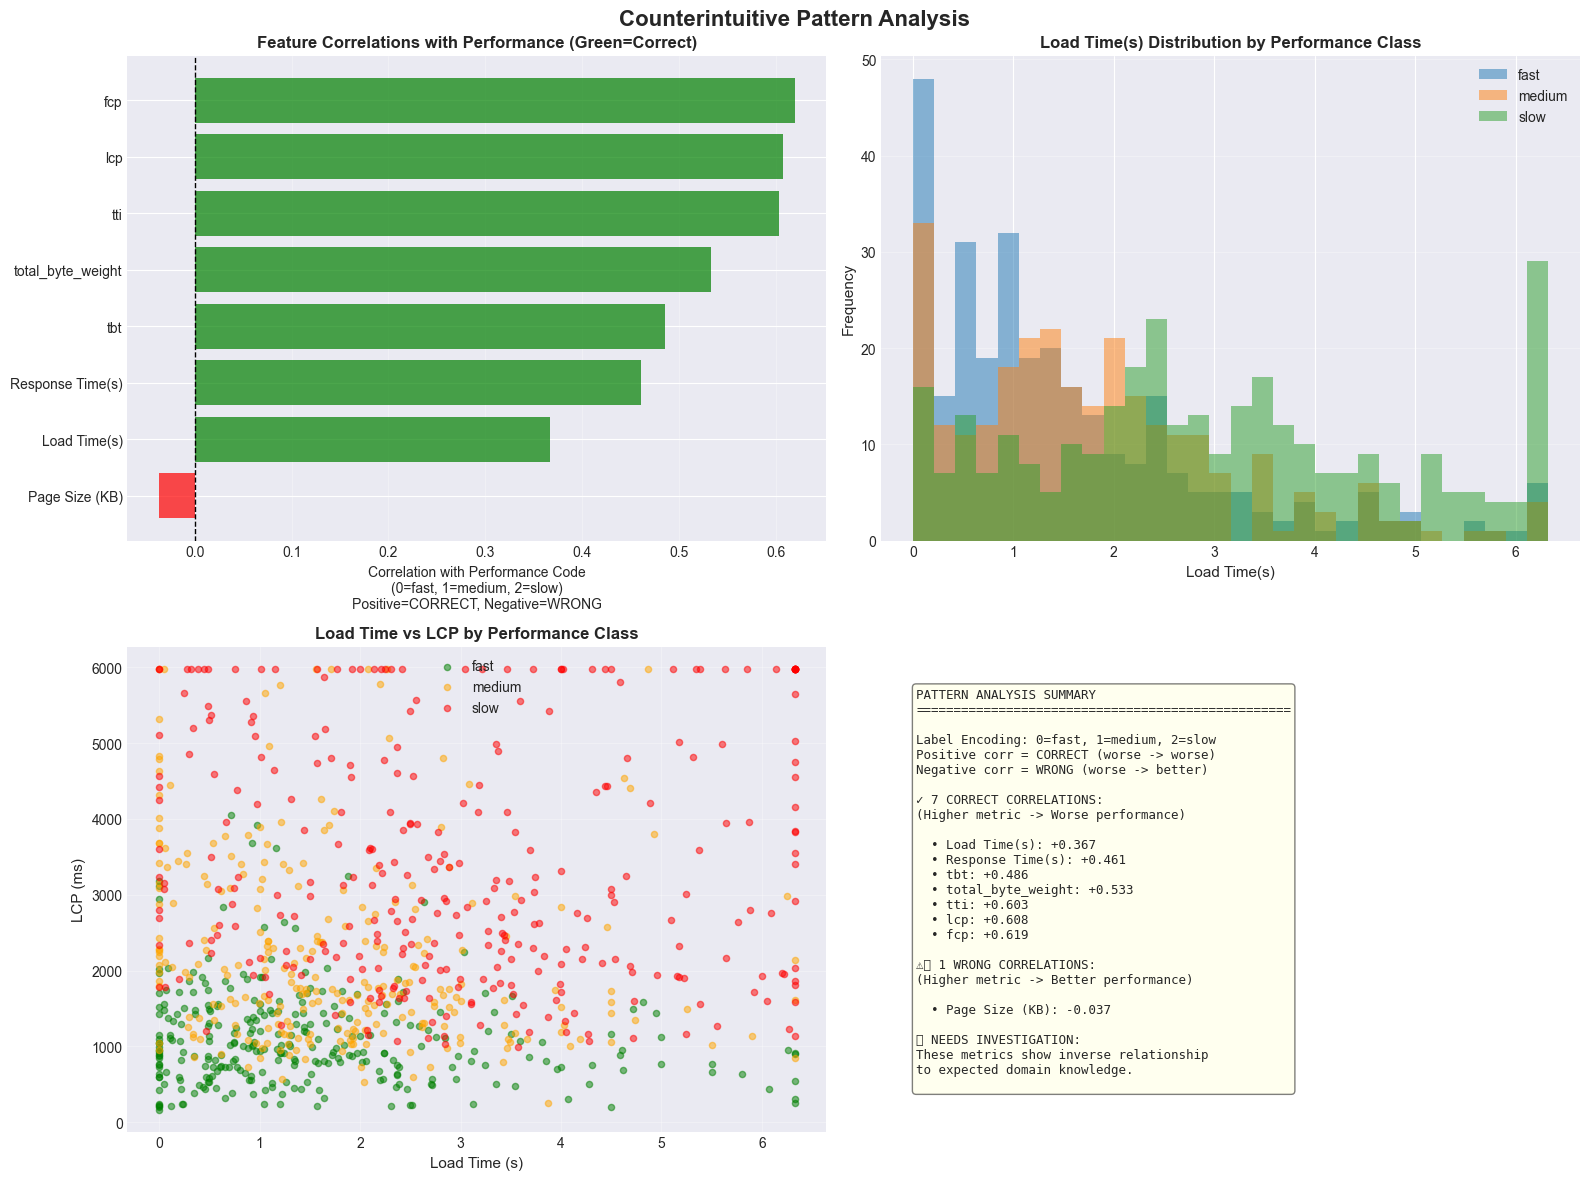


📊 Correlation Analysis:
          Feature  Correlation
   Page Size (KB)    -0.036787
     Load Time(s)     0.367229
 Response Time(s)     0.460728
              tbt     0.485829
total_byte_weight     0.533104
              tti     0.602974
              lcp     0.607841
              fcp     0.619380
        unused_js          NaN

✓ Interpretation: Label encoding is 0=fast, 1=medium, 2=slow
  POSITIVE correlations are CORRECT (worse metrics → worse performance)
  NEGATIVE correlations are WRONG (worse metrics → better performance)

✓ Correct: 7/9 features
✗ Wrong: 1/9 features


In [7]:
def analyze_counterintuitive_patterns(df, model_pkg, feature_names):
    """
    Analyze correlations and patterns that might explain counterintuitive recommendations.
    """
    print("="*80)
    print("ANALYZING COUNTERINTUITIVE PATTERNS")
    print("="*80)
    
    # Features that should typically DECREASE for better performance
    metrics_to_reduce = ['Load Time(s)', 'Response Time(s)', 'Page Size (KB)', 
                         'lcp', 'fcp', 'tti', 'tbt', 'total_byte_weight', 'unused_js']
    
    # Analyze correlation with performance
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Counterintuitive Pattern Analysis', fontsize=16, fontweight='bold')
    
    # 1. Correlation with Performance Label
    target_encoder = model_pkg['encoders']['target']
    df_analysis = df.copy()
    # Remove rows with missing Performance_Label before encoding
    df_analysis = df_analysis[df_analysis['Performance_Label'].notna()].copy()
    df_analysis['Performance_Code'] = target_encoder.transform(df_analysis['Performance_Label'])
    
    correlations = {}
    for feature in metrics_to_reduce:
        if feature in df.columns:
            # Calculate correlation (fast=0, medium=1, slow=2)
            corr = df_analysis[['Performance_Code', feature]].corr().iloc[0, 1]
            correlations[feature] = corr
    
    corr_df = pd.DataFrame(list(correlations.items()), 
                          columns=['Feature', 'Correlation'])
    corr_df = corr_df.sort_values('Correlation')
    
    # Color code: GREEN for positive (correct), RED for negative (wrong)
    # Positive = worse metrics lead to worse performance (CORRECT!)
    # Negative = worse metrics lead to better performance (WRONG!)
    colors = ['green' if c > 0 else 'red' for c in corr_df['Correlation']]
    axes[0, 0].barh(corr_df['Feature'], corr_df['Correlation'], color=colors, alpha=0.7)
    axes[0, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[0, 0].set_xlabel('Correlation with Performance Code\n(0=fast, 1=medium, 2=slow)\nPositive=CORRECT, Negative=WRONG', fontsize=10)
    axes[0, 0].set_title('Feature Correlations with Performance (Green=Correct)', fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # 2. Distribution by Performance Class
    # Select a problematic feature (e.g., Load Time)
    problem_feature = 'Load Time(s)'
    if problem_feature in df.columns:
        for perf_label in ['fast', 'medium', 'slow']:
            data = df[df['Performance_Label'] == perf_label][problem_feature].dropna()
            axes[0, 1].hist(data, alpha=0.5, label=perf_label, bins=30)
        
        axes[0, 1].set_xlabel(f'{problem_feature}', fontsize=11)
        axes[0, 1].set_ylabel('Frequency', fontsize=11)
        axes[0, 1].set_title(f'{problem_feature} Distribution by Performance Class', fontweight='bold')
        axes[0, 1].legend()
        axes[0, 1].grid(axis='y', alpha=0.3)
    
    # 3. Scatter plot: Load Time vs LCP colored by performance
    if 'Load Time(s)' in df.columns and 'lcp' in df.columns:
        for perf_label, color in zip(['fast', 'medium', 'slow'], ['green', 'orange', 'red']):
            subset = df[df['Performance_Label'] == perf_label]
            axes[1, 0].scatter(subset['Load Time(s)'], subset['lcp'], 
                             alpha=0.5, label=perf_label, color=color, s=20)
        
        axes[1, 0].set_xlabel('Load Time (s)', fontsize=11)
        axes[1, 0].set_ylabel('LCP (ms)', fontsize=11)
        axes[1, 0].set_title('Load Time vs LCP by Performance Class', fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)
    
    # 4. Summary statistics
    axes[1, 1].axis('off')
    
    summary_text = "PATTERN ANALYSIS SUMMARY\n"
    summary_text += "="*50 + "\n\n"
    summary_text += "Label Encoding: 0=fast, 1=medium, 2=slow\n"
    summary_text += "Positive corr = CORRECT (worse -> worse)\n"
    summary_text += "Negative corr = WRONG (worse -> better)\n\n"
    
    # Identify CORRECT positive correlations
    correct_positive = corr_df[corr_df['Correlation'] > 0]
    # Identify WRONG negative correlations
    wrong_negative = corr_df[corr_df['Correlation'] < 0]
    
    if len(correct_positive) > 0:
        summary_text += f"✓ {len(correct_positive)} CORRECT CORRELATIONS:\n"
        summary_text += "(Higher metric -> Worse performance)\n\n"
        for _, row in correct_positive.iterrows():
            summary_text += f"  • {row['Feature']}: {row['Correlation']:+.3f}\n"
    
    if len(wrong_negative) > 0:
        summary_text += f"\n⚠️ {len(wrong_negative)} WRONG CORRELATIONS:\n"
        summary_text += "(Higher metric -> Better performance)\n\n"
        for _, row in wrong_negative.iterrows():
            summary_text += f"  • {row['Feature']}: {row['Correlation']:+.3f}\n"
        
        summary_text += "\n💡 NEEDS INVESTIGATION:\n"
        summary_text += "These metrics show inverse relationship\n"
        summary_text += "to expected domain knowledge.\n"
    else:
        summary_text += "\n✓ All correlations align with\n"
        summary_text += "  web performance best practices!\n"
    
    axes[1, 1].text(0.05, 0.5, summary_text,
                   fontsize=9, family='monospace',
                   verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Correlation Analysis:")
    print(corr_df.to_string(index=False))
    print("\n✓ Interpretation: Label encoding is 0=fast, 1=medium, 2=slow")
    print("  POSITIVE correlations are CORRECT (worse metrics → worse performance)")
    print("  NEGATIVE correlations are WRONG (worse metrics → better performance)")
    print(f"\n✓ Correct: {len(corr_df[corr_df['Correlation'] > 0])}/{len(corr_df)} features")
    print(f"✗ Wrong: {len(corr_df[corr_df['Correlation'] < 0])}/{len(corr_df)} features")
    print("="*80)
    
    return corr_df

# Analyze patterns
correlation_analysis = analyze_counterintuitive_patterns(df, model_pkg, feature_names)

## 7. LIME Analysis - Local Explanations

**Goal:** Explain specific predictions, especially counterintuitive optimization cases.

In [8]:
# LIME Explainer - Create LIME explainer for local interpretability
def create_lime_explainer(X_original, feature_names, class_names=['fast', 'medium', 'slow']):
    """
    Create LIME explainer for local interpretability.
    """
    print("="*80)
    print("CREATING LIME EXPLAINER")
    print("="*80)
    
    # Create LIME explainer
    explainer = lime_tabular.LimeTabularExplainer(
        training_data=X_original.values,
        feature_names=feature_names,
        class_names=class_names,
        mode='classification',
        discretize_continuous=True,
        random_state=42
    )
    
    print("✓ LIME explainer created successfully!")
    print(f"  Training samples: {X_original.shape[0]}")
    print(f"  Features: {len(feature_names)}")
    print(f"  Classes: {len(class_names)}")
    print("="*80)
    
    return explainer

# Create LIME explainer
lime_explainer = create_lime_explainer(X_original, feature_names)

CREATING LIME EXPLAINER
✓ LIME explainer created successfully!
  Training samples: 885
  Features: 20
  Classes: 3


In [9]:
# LIME Explanations - Generate explanations for specific samples
def explain_predictions_with_lime(lime_explainer, model_pkg, X_original, X_scaled, y, 
                                  sample_indices, feature_names):
    """
    Generate LIME explanations for specific samples.
    """
    print("="*80)
    print("LIME EXPLANATIONS FOR SPECIFIC PREDICTIONS")
    print("="*80)
    
    model = model_pkg['model']
    scaler = model_pkg['scaler']
    target_encoder = model_pkg['encoders']['target']
    class_names = target_encoder.classes_
    
    # Wrapper function for LIME
    def predict_fn(X):
        X_scaled = scaler.transform(X)
        return model.predict_proba(X_scaled)
    
    explanations = []
    
    for idx in sample_indices:
        print(f"\n{'='*60}")
        print(f"Explaining Sample {idx}")
        print(f"{'='*60}")
        
        # Get prediction
        pred_proba = model.predict_proba(X_scaled[idx:idx+1])[0]
        pred_class = model.predict(X_scaled[idx:idx+1])[0]
        true_class = y[idx]
        
        print(f"\nActual class: {class_names[true_class]}")
        print(f"Predicted class: {class_names[pred_class]}")
        print(f"Probabilities: Fast={pred_proba[0]:.3f}, Medium={pred_proba[1]:.3f}, Slow={pred_proba[2]:.3f}")
        
        # Generate explanation
        explanation = lime_explainer.explain_instance(
            data_row=X_original.iloc[idx].values,
            predict_fn=predict_fn,
            num_features=10,
            top_labels=3
        )
        
        explanations.append(explanation)
        
        # Show explanation for predicted class
        print(f"\nTop features influencing prediction toward '{class_names[pred_class]}':")
        for feature, weight in explanation.as_list(label=pred_class):
            direction = "↑ INCREASES" if weight > 0 else "↓ DECREASES"
            print(f"  {direction} probability: {feature} (weight: {weight:+.4f})")
    
    print("\n" + "="*80)
    
    return explanations

# Select interesting samples for explanation
fast_indices = np.where((y == 0) & (model_pkg['model'].predict(X_scaled) == 0))[0]
slow_indices = np.where((y == 2) & (model_pkg['model'].predict(X_scaled) == 2))[0]
misclassified = np.where(model_pkg['model'].predict(X_scaled) != y)[0]

sample_indices = []
if len(fast_indices) > 0:
    sample_indices.append(fast_indices[0])
if len(slow_indices) > 0:
    sample_indices.append(slow_indices[0])
if len(misclassified) > 0:
    sample_indices.append(misclassified[0])

# Generate LIME explanations
lime_explanations = explain_predictions_with_lime(
    lime_explainer, model_pkg, X_original, X_scaled, y, 
    sample_indices, feature_names
)

LIME EXPLANATIONS FOR SPECIFIC PREDICTIONS

Explaining Sample 1

Actual class: fast
Predicted class: fast
Probabilities: Fast=0.992, Medium=0.008, Slow=0.000

Top features influencing prediction toward 'fast':
  ↑ INCREASES probability: Response Time(s) <= 0.39 (weight: +0.2938)
  ↑ INCREASES probability: tti <= 1814.96 (weight: +0.2554)
  ↑ INCREASES probability: Total_Time <= 1.58 (weight: +0.1825)
  ↑ INCREASES probability: performance_score > 87.00 (weight: +0.1800)
  ↓ DECREASES probability: 805.21 < fcp <= 1068.75 (weight: -0.1577)
  ↑ INCREASES probability: 1102.01 < lcp <= 1762.03 (weight: +0.0400)
  ↑ INCREASES probability: tbt <= 36.00 (weight: +0.0358)
  ↓ DECREASES probability: Throughput_ResponseTime_Ratio <= 69.30 (weight: -0.0264)
  ↑ INCREASES probability: 51.00 < num_requests <= 102.00 (weight: +0.0218)
  ↑ INCREASES probability: Log_Throughput <= 4.11 (weight: +0.0215)

Explaining Sample 4

Actual class: slow
Predicted class: slow
Probabilities: Fast=0.001, Medium=0.1

## 8. Visualize LIME Explanations

VISUALIZING LIME EXPLANATIONS


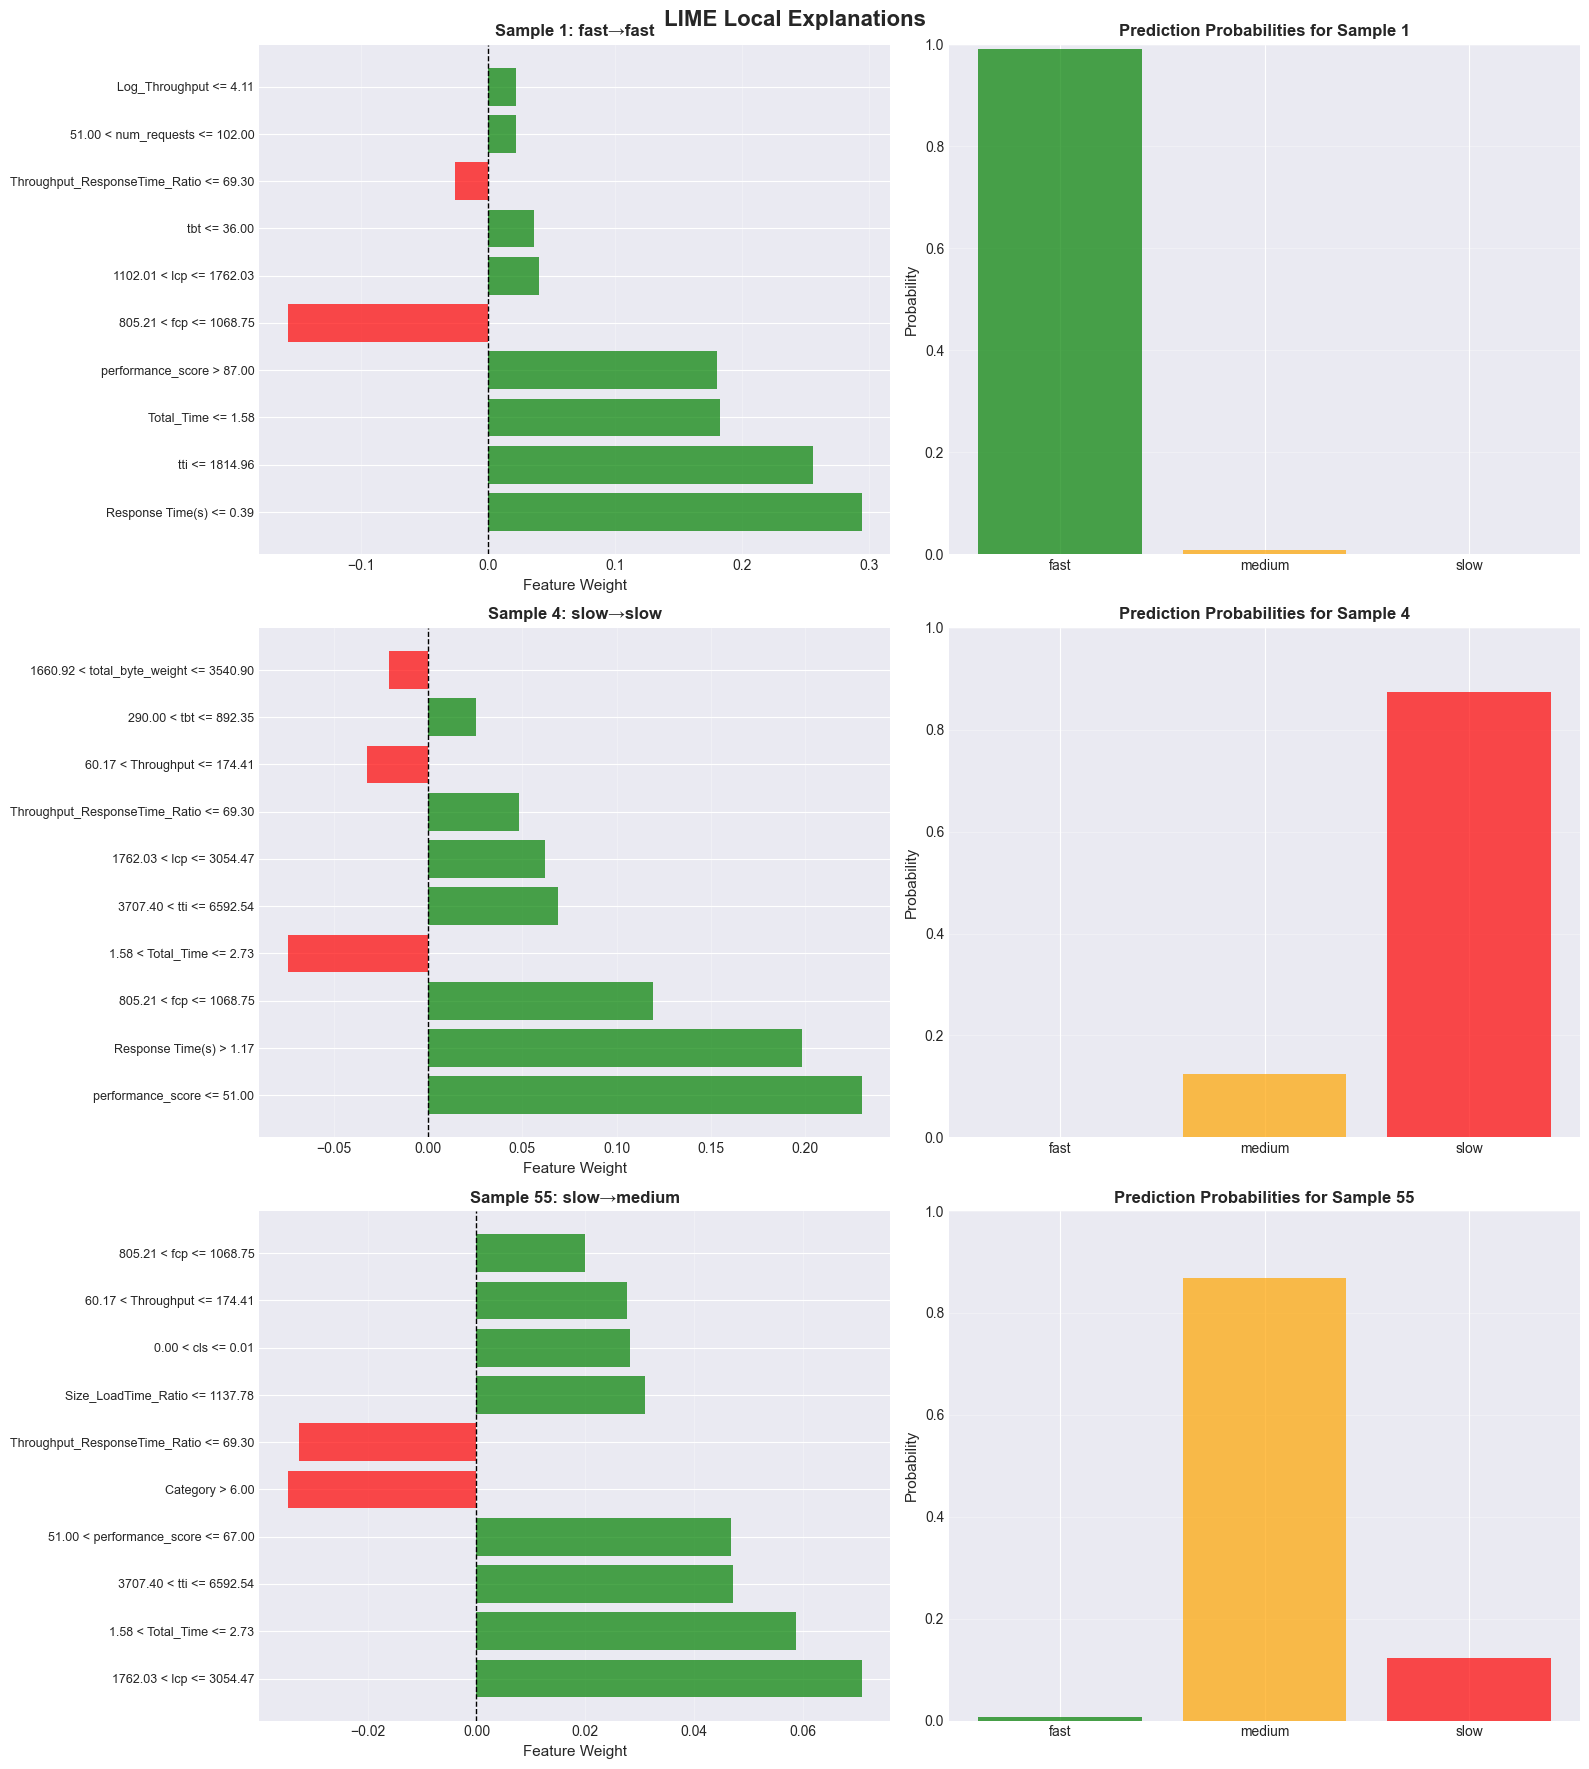

✓ LIME visualizations created!


In [10]:
# LIME Visualization
def visualize_lime_explanations(lime_explanations, X_original, y, sample_indices, 
                                model_pkg, X_scaled):
    """
    Create visualizations for LIME explanations.
    """
    print("="*80)
    print("VISUALIZING LIME EXPLANATIONS")
    print("="*80)
    
    class_names = model_pkg['encoders']['target'].classes_
    model = model_pkg['model']
    
    num_samples = len(lime_explanations)
    fig, axes = plt.subplots(num_samples, 2, figsize=(16, 6*num_samples))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle('LIME Local Explanations', fontsize=16, fontweight='bold')
    
    for i, (explanation, idx) in enumerate(zip(lime_explanations, sample_indices)):
        pred_proba = model.predict_proba(X_scaled[idx:idx+1])[0]
        pred_class = model.predict(X_scaled[idx:idx+1])[0]
        true_class = y[idx]
        
        exp_list = explanation.as_list(label=pred_class)
        
        features = [item[0] for item in exp_list[:10]]
        weights = [item[1] for item in exp_list[:10]]
        colors = ['green' if w > 0 else 'red' for w in weights]
        
        axes[i, 0].barh(range(len(features)), weights, color=colors, alpha=0.7)
        axes[i, 0].set_yticks(range(len(features)))
        axes[i, 0].set_yticklabels(features, fontsize=9)
        axes[i, 0].set_xlabel('Feature Weight', fontsize=11)
        axes[i, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
        axes[i, 0].set_title(f'Sample {idx}: {class_names[true_class]}→{class_names[pred_class]}', fontweight='bold')
        axes[i, 0].grid(axis='x', alpha=0.3)
        
        axes[i, 1].bar(class_names, pred_proba, color=['green', 'orange', 'red'], alpha=0.7)
        axes[i, 1].set_ylabel('Probability', fontsize=11)
        axes[i, 1].set_title(f'Prediction Probabilities for Sample {idx}', fontweight='bold')
        axes[i, 1].set_ylim([0, 1])
        axes[i, 1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ LIME visualizations created!")
    print("="*80)

visualize_lime_explanations(lime_explanations, X_original, y, sample_indices, model_pkg, X_scaled)

## 9. Feature Interaction Analysis

**Goal:** Detect complex interactions that might explain counterintuitive behavior.

FEATURE INTERACTION ANALYSIS

This may take a few minutes...

📊 Analyzing top 5 features for interactions...
SHAP values shape for 'fast' class: (885, 20)

Top 5 features for interaction analysis:
  1. fcp (mean |SHAP|: 0.9176)
  2. Response Time(s) (mean |SHAP|: 0.8808)
  3. lcp (mean |SHAP|: 0.7948)
  4. tti (mean |SHAP|: 0.5900)
  5. performance_score (mean |SHAP|: 0.5879)


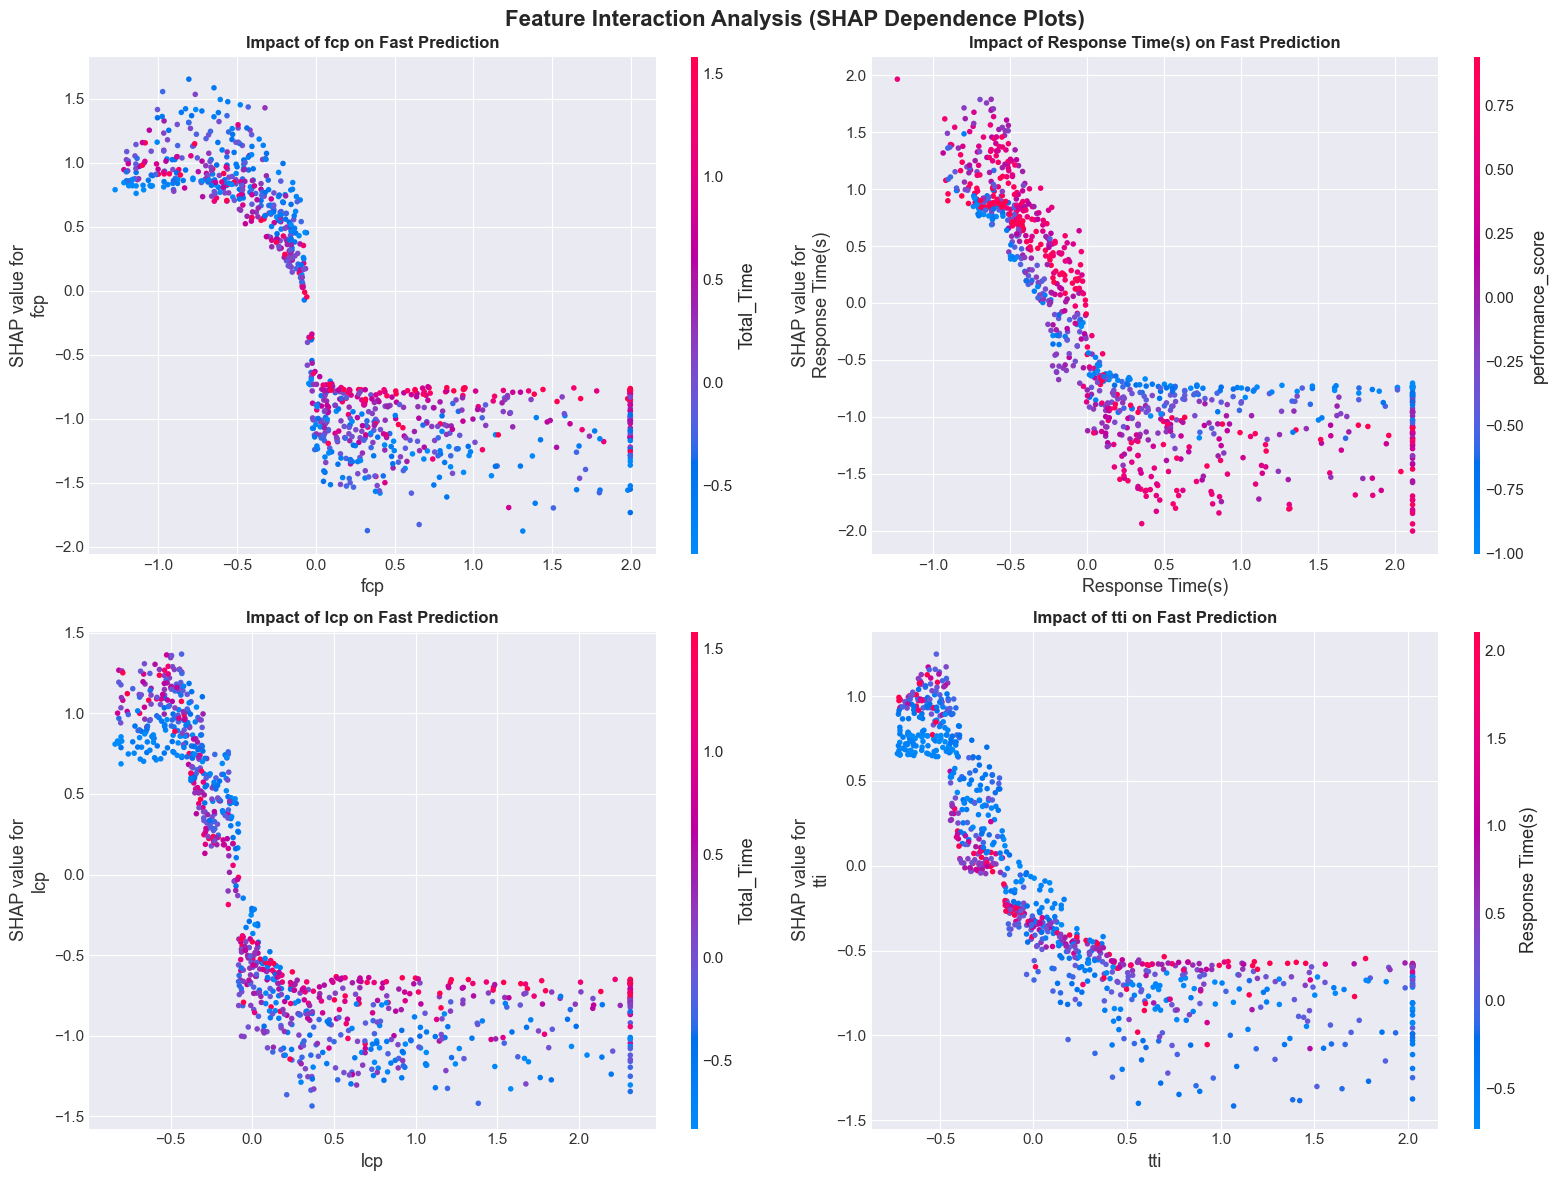


📊 Interpretation Guide:
  • X-axis: Feature value
  • Y-axis: SHAP value (impact on prediction)
  • Color: Another feature's value (automatic selection)
  • Vertical spread indicates interactions with other features


In [11]:
def analyze_feature_interactions(shap_values, X_scaled, feature_names, 
                                top_features=5):
    """
    Analyze feature interactions using SHAP interaction values.
    """
    print("="*80)
    print("FEATURE INTERACTION ANALYSIS")
    print("="*80)
    print("\nThis may take a few minutes...")
    
    # Handle different SHAP formats - extract 'fast' class values (index 0)
    if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
        # 3D array: (samples, features, classes) - extract first class
        shap_values_fast = shap_values[:, :, 0]
    else:
        # List format - get first class
        shap_values_fast = shap_values[0]
    
    print(f"\n📊 Analyzing top {top_features} features for interactions...")
    print(f"SHAP values shape for 'fast' class: {shap_values_fast.shape}")
    
    # Get mean absolute SHAP values to identify top features
    mean_abs_shap = np.abs(shap_values_fast).mean(axis=0)
    top_feature_indices = np.argsort(mean_abs_shap)[-top_features:][::-1]
    top_feature_names = [feature_names[i] for i in top_feature_indices]
    
    print(f"\nTop {top_features} features for interaction analysis:")
    for i, (idx, name) in enumerate(zip(top_feature_indices, top_feature_names), 1):
        print(f"  {i}. {name} (mean |SHAP|: {mean_abs_shap[idx]:.4f})")
    
    # Create interaction plots for top feature pairs
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Feature Interaction Analysis (SHAP Dependence Plots)', 
                fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    # Plot dependence plots for top 4 features
    for i, (idx, name) in enumerate(zip(top_feature_indices[:4], top_feature_names[:4])):
        ax = axes[i]
        
        # SHAP dependence plot
        # Use feature name instead of index to avoid indexing issues
        shap.dependence_plot(
            name,  # Use feature name instead of index
            shap_values_fast, 
            X_scaled,
            feature_names=feature_names,
            show=False,
            ax=ax
        )
        ax.set_title(f'Impact of {name} on Fast Prediction', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Interpretation Guide:")
    print("  • X-axis: Feature value")
    print("  • Y-axis: SHAP value (impact on prediction)")
    print("  • Color: Another feature's value (automatic selection)")
    print("  • Vertical spread indicates interactions with other features")
    print("="*80)

# Analyze feature interactions
analyze_feature_interactions(shap_values, X_scaled, feature_names, top_features=5)

## 10. Data Quality Assessment

**Goal:** Detect potential data quality issues that might cause spurious patterns.

In [12]:
def assess_data_quality(df, feature_names):
    """
    Assess data quality to identify potential issues.
    """
    print("="*80)
    print("DATA QUALITY ASSESSMENT")
    print("="*80)
    
    issues = []
    
    # Check for missing values
    print("\n1. Missing Values Analysis:")
    missing = df[feature_names[:15]].isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    
    if missing.sum() > 0:
        print("\n⚠️  Features with missing values:")
        for feat, count, pct in zip(missing.index, missing.values, missing_pct.values):
            if count > 0:
                print(f"  • {feat}: {count} ({pct}%)")
                issues.append(f"Missing values in {feat}: {pct}%")
    else:
        print("✓ No missing values detected")
    
    # Check for outliers using IQR method
    print("\n2. Outlier Detection (IQR method):")
    numeric_features = df[feature_names[:15]].select_dtypes(include=[np.number]).columns
    
    outlier_summary = []
    for feature in numeric_features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        
        outliers = ((df[feature] < lower_bound) | (df[feature] > upper_bound)).sum()
        outlier_pct = (outliers / len(df) * 100).round(2)
        
        if outlier_pct > 5:  # More than 5% outliers
            outlier_summary.append((feature, outliers, outlier_pct))
    
    if len(outlier_summary) > 0:
        print("\n⚠️  Features with high outlier percentage (>5%):")
        for feat, count, pct in outlier_summary:
            print(f"  • {feat}: {count} ({pct}%)")
            issues.append(f"High outliers in {feat}: {pct}%")
    else:
        print("✓ No excessive outliers detected")
    
    # Check for constant or near-constant features
    print("\n3. Low Variance Features:")
    for feature in numeric_features:
        if df[feature].std() < 0.01:
            print(f"⚠️  {feature} has very low variance: {df[feature].std():.6f}")
            issues.append(f"Low variance in {feature}")
    
    # Check for duplicate rows
    print("\n4. Duplicate Detection:")
    duplicates = df[feature_names[:15]].duplicated().sum()
    if duplicates > 0:
        print(f"⚠️  Found {duplicates} duplicate rows")
        issues.append(f"Duplicate rows: {duplicates}")
    else:
        print("✓ No duplicate rows detected")
    
    # Check class imbalance
    print("\n5. Class Balance:")
    class_dist = df['Performance_Label'].value_counts()
    class_pct = (class_dist / len(df) * 100).round(2)
    
    print("\nClass distribution:")
    for cls, count, pct in zip(class_dist.index, class_dist.values, class_pct.values):
        print(f"  • {cls}: {count} ({pct}%)")
    
    min_class_pct = class_pct.min()
    if min_class_pct < 15:
        print(f"\n⚠️  Class imbalance detected! Smallest class: {min_class_pct}%")
        issues.append(f"Class imbalance: smallest class {min_class_pct}%")
    else:
        print("\n✓ Classes reasonably balanced")
    
    # Summary
    print("\n" + "="*80)
    print("DATA QUALITY SUMMARY")
    print("="*80)
    
    if len(issues) == 0:
        print("✓ No major data quality issues detected!")
    else:
        print(f"⚠️  Found {len(issues)} potential issues:")
        for i, issue in enumerate(issues, 1):
            print(f"  {i}. {issue}")
    
    print("="*80)
    
    return issues

# Assess data quality
data_quality_issues = assess_data_quality(df, feature_names)

DATA QUALITY ASSESSMENT

1. Missing Values Analysis:
✓ No missing values detected

2. Outlier Detection (IQR method):
✓ No excessive outliers detected

3. Low Variance Features:
⚠️  unused_js has very low variance: 0.000000

4. Duplicate Detection:
✓ No duplicate rows detected

5. Class Balance:

Class distribution:
  • slow: 315 (35.59%)
  • fast: 299 (33.79%)
  • medium: 271 (30.62%)

✓ Classes reasonably balanced

DATA QUALITY SUMMARY
⚠️  Found 1 potential issues:
  1. Low variance in unused_js


## 11. Validation: Model vs. Domain Knowledge

**Goal:** Compare model's learned patterns with web performance best practices.

In [13]:
def validate_model_patterns(mean_shap_df, correlation_analysis):
    """
    Validate model patterns against domain knowledge.
    """
    print("="*80)
    print("MODEL VALIDATION AGAINST DOMAIN KNOWLEDGE")
    print("="*80)
    
    # Expected patterns from web performance best practices
    # IMPORTANT: Labels are encoded as 0=fast (best), 1=medium, 2=slow (worst)
    # So POSITIVE correlation means: higher metric → higher label code → WORSE performance (CORRECT!)
    # And NEGATIVE correlation means: higher metric → lower label code → BETTER performance (WRONG!)
    expected_patterns = {
        'Load Time(s)': 'POSITIVE',  # Higher load time = worse performance
        'Response Time(s)': 'POSITIVE',  # Higher response time = worse performance
        'Page Size (KB)': 'POSITIVE',  # Larger page = worse performance
        'lcp': 'POSITIVE',  # Higher LCP = worse performance
        'fcp': 'POSITIVE',  # Higher FCP = worse performance
        'cls': 'POSITIVE',  # Higher CLS = worse performance
        'tti': 'POSITIVE',  # Higher TTI = worse performance
        'tbt': 'POSITIVE',  # Higher TBT = worse performance
        'speed_index': 'POSITIVE',  # Higher speed index = worse performance
        'total_byte_weight': 'POSITIVE',  # More bytes = worse performance
        'unused_js': 'POSITIVE',  # More unused JS = worse performance
        'Throughput': 'NEGATIVE',  # Higher throughput = better performance (lower label code)
        'num_requests': 'POSITIVE'  # More requests = worse performance
    }
    
    # Analyze each feature
    validation_results = []
    
    print("\n📊 Feature-by-Feature Validation:\n")
    print("NOTE: Label encoding: 0=fast (best), 1=medium, 2=slow (worst)")
    print("Positive correlation = worse metric → worse performance (CORRECT)")
    print("Negative correlation = worse metric → better performance (WRONG)\n")
    
    for feature, expected in expected_patterns.items():
        if feature in correlation_analysis['Feature'].values:
            # Get correlation (from counterintuitive analysis)
            corr_row = correlation_analysis[correlation_analysis['Feature'] == feature]
            if len(corr_row) > 0:
                correlation = corr_row['Correlation'].values[0]
                
                # Check if pattern matches expectation (considering label encoding)
                if expected == 'POSITIVE' and correlation > 0:
                    status = "✓ CORRECT"
                    validation_results.append((feature, 'PASS', correlation))
                elif expected == 'NEGATIVE' and correlation < 0:
                    status = "✓ CORRECT"
                    validation_results.append((feature, 'PASS', correlation))
                else:
                    status = "✗ WRONG"
                    validation_results.append((feature, 'FAIL', correlation))
                
                print(f"{status:12} | {feature:25} | Expected: {expected:8} | Actual: {correlation:+.3f}")
    
    # Summary
    print("\n" + "="*80)
    print("VALIDATION SUMMARY")
    print("="*80)
    
    passed = sum(1 for _, status, _ in validation_results if status == 'PASS')
    total = len(validation_results)
    
    print(f"\n✓ Passed: {passed}/{total} ({passed/total*100:.1f}%)")
    print(f"✗ Failed: {total-passed}/{total} ({(total-passed)/total*100:.1f}%)")
    
    if passed < total:
        print("\n⚠️  FAILED VALIDATIONS:")
        for feature, status, corr in validation_results:
            if status == 'FAIL':
                print(f"  • {feature}: correlation = {corr:+.3f}")
        
        print("\n💡 RECOMMENDATIONS:")
        print("  1. Investigate data collection methodology")
        print("  2. Check for confounding variables")
        print("  3. Consider retraining with data quality fixes")
        print("  4. Add domain constraints to optimization")
        print("  5. Use ensemble methods with domain rules")
    else:
        print("\n✓ All patterns align with domain knowledge!")
    
    print("="*80)
    
    return validation_results

# Validate model patterns
validation_results = validate_model_patterns(mean_shap_df, correlation_analysis)

MODEL VALIDATION AGAINST DOMAIN KNOWLEDGE

📊 Feature-by-Feature Validation:

NOTE: Label encoding: 0=fast (best), 1=medium, 2=slow (worst)
Positive correlation = worse metric → worse performance (CORRECT)
Negative correlation = worse metric → better performance (WRONG)

✓ CORRECT    | Load Time(s)              | Expected: POSITIVE | Actual: +0.367
✓ CORRECT    | Response Time(s)          | Expected: POSITIVE | Actual: +0.461
✗ WRONG      | Page Size (KB)            | Expected: POSITIVE | Actual: -0.037
✓ CORRECT    | lcp                       | Expected: POSITIVE | Actual: +0.608
✓ CORRECT    | fcp                       | Expected: POSITIVE | Actual: +0.619
✓ CORRECT    | tti                       | Expected: POSITIVE | Actual: +0.603
✓ CORRECT    | tbt                       | Expected: POSITIVE | Actual: +0.486
✓ CORRECT    | total_byte_weight         | Expected: POSITIVE | Actual: +0.533
✗ WRONG      | unused_js                 | Expected: POSITIVE | Actual: +nan

VALIDATION SUMMARY


## 12. Generate Comprehensive Explainability Report

In [14]:
def generate_explainability_report(mean_shap_df, correlation_analysis, 
                                  validation_results, data_quality_issues):
    """
    Generate a comprehensive explainability report.
    """
    print("="*80)
    print("PHASE 3 EXPLAINABILITY REPORT")
    print("="*80)
    
    # Get top features
    top_5_features = mean_shap_df.sum(axis=1).nlargest(5)
    
    print("\n" + "="*80)
    print("1. MODEL FEATURE RELIANCE")
    print("="*80)
    
    print("\nTop 5 Most Important Features:")
    for rank, (feature, importance) in enumerate(top_5_features.items(), 1):
        print(f"  {rank}. {feature:30} (SHAP: {importance:.4f})")
    
    print("\n📊 Key Finding:")
    print(f"  The model relies most heavily on: {top_5_features.index[0]}")
    print(f"  Top 3 features account for {(top_5_features.iloc[:3].sum() / top_5_features.sum() * 100):.1f}% of total importance")
    
    print("\n" + "="*80)
    print("2. CORRELATION PATTERN VALIDATION")
    print("="*80)
    
    print("\n📊 Label Encoding: 0=fast (best), 1=medium, 2=slow (worst)")
    print("   POSITIVE correlation = worse metrics lead to worse performance (CORRECT ✓)")
    print("   NEGATIVE correlation = worse metrics lead to better performance (WRONG ✗)")
    
    # Identify CORRECT positive correlations
    correct_patterns = correlation_analysis[correlation_analysis['Correlation'] > 0]
    # Identify WRONG negative correlations
    wrong_patterns = correlation_analysis[correlation_analysis['Correlation'] < 0]
    
    if len(correct_patterns) > 0:
        print(f"\n✓ Found {len(correct_patterns)} CORRECT correlation patterns:")
        for _, row in correct_patterns.iterrows():
            print(f"  • {row['Feature']:30} correlation: {row['Correlation']:+.3f}")
    
    if len(wrong_patterns) > 0:
        print(f"\n⚠️  Found {len(wrong_patterns)} WRONG correlation patterns:")
        for _, row in wrong_patterns.iterrows():
            print(f"  • {row['Feature']:30} correlation: {row['Correlation']:+.3f}")
        
        print("\n💡 Explanation:")
        print("  These features show NEGATIVE correlation, meaning higher values")
        print("  correlate with BETTER performance, which contradicts domain knowledge.")
        print("  This may indicate data quality issues or confounding variables.")
    else:
        print("\n✓ All correlations align with domain knowledge!")
    
    print("\n" + "="*80)
    print("3. DATA QUALITY ISSUES")
    print("="*80)
    
    if len(data_quality_issues) > 0:
        print(f"\n⚠️  Found {len(data_quality_issues)} data quality issues:")
        for i, issue in enumerate(data_quality_issues, 1):
            print(f"  {i}. {issue}")
        
        print("\n💡 Impact:")
        print("  Data quality issues can cause the model to learn incorrect")
        print("  patterns, leading to unreliable predictions and recommendations.")
    else:
        print("\n✓ No major data quality issues detected!")
    
    print("\n" + "="*80)
    print("4. PATTERN VALIDATION")
    print("="*80)
    
    passed = sum(1 for _, status, _ in validation_results if status == 'PASS')
    total = len(validation_results)
    
    print(f"\nModel Pattern Validation: {passed}/{total} passed ({passed/total*100:.1f}%)")
    
    failed_features = [feature for feature, status, _ in validation_results if status == 'FAIL']
    
    if len(failed_features) > 0:
        print("\n⚠️  Features with patterns contradicting domain knowledge:")
        for feature in failed_features:
            print(f"  • {feature}")
        
        print("\n💡 Conclusion:")
        print("  These features show unexpected patterns that need investigation.")
    else:
        print("\n✓ All patterns align with web performance best practices!")
    
    print("\n" + "="*80)
    print("5. RECOMMENDATIONS FOR IMPROVEMENT")
    print("="*80)
    
    print("\nBased on explainability analysis, we recommend:")
    
    # Check for wrong patterns (negative correlations)
    wrong_patterns = correlation_analysis[correlation_analysis['Correlation'] < 0]
    
    if len(wrong_patterns) > 0 or len(failed_features) > 0:
        print("\n📋 Data & Model Improvements:")
        print("  1. Review data collection methodology")
        print("  2. Remove or fix problematic samples with outliers")
        print("  3. Add data validation rules during collection")
        print("  4. Increase dataset size for better generalization")
        print("  5. Balance classes if needed")
        
        print("\n📋 Optimization Improvements:")
        print("  6. Add domain constraints to optimization")
        print("     (e.g., Load Time must decrease)")
        print("  7. Use hybrid approach: ML + domain rules")
        print("  8. Implement sanity checks for recommendations")
        print("  9. Weight SHAP importance in optimization")
        print("  10. Create multiple optimization strategies")
    else:
        print("\n✓ Model is learning correct patterns!")
        print("  1. Continue using current optimization approach")
        print("  2. Monitor for data drift over time")
        print("  3. Regularly retrain with new data")
    
    print("\n" + "="*80)
    print("PHASE 3 COMPLETE - EXPLAINABILITY ANALYSIS")
    print("="*80)
    
    print("\n✅ COMPLETED TASKS:")
    print("  1. Computed SHAP values for global feature importance")
    print("  2. Analyzed counterintuitive patterns in correlations")
    print("  3. Generated LIME explanations for local interpretability")
    print("  4. Analyzed feature interactions")
    print("  5. Assessed data quality")
    print("  6. Validated model patterns vs. domain knowledge")
    print("  7. Generated comprehensive explainability report")
    
    print("\n📊 KEY INSIGHTS:")
    print(f"  • Model relies on {len(top_5_features)} primary features")
    correct_corr = len(correlation_analysis[correlation_analysis['Correlation'] > 0])
    total_corr = len(correlation_analysis)
    print(f"  • {correct_corr}/{total_corr} features show correct correlation patterns")
    print(f"  • {len(data_quality_issues)} data quality issues found")
    print(f"  • {passed}/{total} features validated correctly")
    
    print("\n🎯 NEXT STEPS:")
    wrong_patterns = correlation_analysis[correlation_analysis['Correlation'] < 0]
    if len(wrong_patterns) > 0 or len(failed_features) > 0:
        print("  ⚠️  Investigate features with unexpected patterns")
        print("  → Review data collection for affected features")
        print("  → Consider feature engineering or transformation")
        print("  → Add validation layers to recommendations")
    else:
        print("  ✓ Model ready for production deployment")
        print("  → Monitor performance in real-world scenarios")
        print("  → Collect feedback on recommendations")
        print("  → Continuously improve with new data")
    
    print("\n" + "="*80)

# Generate final report
generate_explainability_report(mean_shap_df, correlation_analysis, 
                              validation_results, data_quality_issues)

PHASE 3 EXPLAINABILITY REPORT

1. MODEL FEATURE RELIANCE

Top 5 Most Important Features:
  1. fcp                            (SHAP: 2.1676)
  2. Response Time(s)               (SHAP: 1.8725)
  3. performance_score              (SHAP: 1.6853)
  4. lcp                            (SHAP: 1.5847)
  5. Total_Time                     (SHAP: 1.4624)

📊 Key Finding:
  The model relies most heavily on: fcp
  Top 3 features account for 65.3% of total importance

2. CORRELATION PATTERN VALIDATION

📊 Label Encoding: 0=fast (best), 1=medium, 2=slow (worst)
   POSITIVE correlation = worse metrics lead to worse performance (CORRECT ✓)
   NEGATIVE correlation = worse metrics lead to better performance (WRONG ✗)

✓ Found 7 CORRECT correlation patterns:
  • Load Time(s)                   correlation: +0.367
  • Response Time(s)               correlation: +0.461
  • tbt                            correlation: +0.486
  • total_byte_weight              correlation: +0.533
  • tti                            

## 13. Export Results for Documentation

In [15]:
# Export key findings to CSV for further analysis

# 1. SHAP feature importance
shap_importance_export = mean_shap_df.copy()
shap_importance_export['total_importance'] = shap_importance_export.sum(axis=1)
shap_importance_export = shap_importance_export.sort_values('total_importance', ascending=False)
shap_importance_export.to_csv('phase3_shap_feature_importance.csv')

# 2. Correlation analysis
correlation_analysis.to_csv('phase3_correlation_analysis.csv', index=False)

# 3. Validation results
validation_df = pd.DataFrame(validation_results, 
                             columns=['Feature', 'Validation_Status', 'Correlation'])
validation_df.to_csv('phase3_validation_results.csv', index=False)

# 4. Data quality issues
if len(data_quality_issues) > 0:
    quality_df = pd.DataFrame({'Issue': data_quality_issues})
    quality_df.to_csv('phase3_data_quality_issues.csv', index=False)

print("="*80)
print("RESULTS EXPORTED")
print("="*80)
print("\nExported files:")
print("  ✓ phase3_shap_feature_importance.csv")
print("  ✓ phase3_correlation_analysis.csv")
print("  ✓ phase3_validation_results.csv")
if len(data_quality_issues) > 0:
    print("  ✓ phase3_data_quality_issues.csv")
print("="*80)

RESULTS EXPORTED

Exported files:
  ✓ phase3_shap_feature_importance.csv
  ✓ phase3_correlation_analysis.csv
  ✓ phase3_validation_results.csv
  ✓ phase3_data_quality_issues.csv
